# Time Series Analysis: Polish National Power Grid (PSE)
## 03. Machine Learning Forecasting (XGBoost) & Feature Engineering

**Business Objective:** Construct a non-linear gradient-boosted tree model (XGBoost Regressor) leveraging temporal lag features, rolling statistics, and cyclical calendar encodings evaluated via temporal cross-validation (`TimeSeriesSplit`).


In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit

sys.path.append(os.path.abspath('..'))
from src.time_series_utils import create_time_features, calculate_metrics
from src.visualization import plot_residual_diagnostics, plot_forecast_comparison

%matplotlib inline
plt.rcParams['figure.dpi'] = 100


### 1. Feature Engineering (Lags $t-1, t-2, t-24, t-168$, Rolling Windows 6h/24h/168h, Trigonometric $\sin/\cos$)

In [2]:
df = pd.read_csv('../data/processed/pse_hourly_data.csv', index_col='dtime', parse_dates=True)
df_features = create_time_features(df, target_col='demand', lags=[1, 2, 3, 24, 48, 168], rolling_windows=[6, 24, 168]).dropna()

print(f"Feature matrix dimensions: {df_features.shape[0]} samples x {df_features.shape[1]} features")
print(f"Engineered feature list: {[c for c in df_features.columns if c not in ['demand', 'demand_diff1', 'demand_diff_seasonal', 'demand_diff_both']]}")
df_features.head(3)


Feature matrix dimensions: 582 samples x 36 features
Engineered feature list: ['pv', 'wi', 'jg', 'oze_total', 'net_demand', 'hour', 'dayofweek', 'day', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'demand_lag_1', 'demand_lag_2', 'demand_lag_3', 'demand_lag_24', 'demand_lag_48', 'demand_lag_168', 'demand_roll_mean_6', 'demand_roll_std_6', 'demand_roll_min_6', 'demand_roll_max_6', 'demand_roll_mean_24', 'demand_roll_std_24', 'demand_roll_min_24', 'demand_roll_max_24', 'demand_roll_mean_168', 'demand_roll_std_168', 'demand_roll_min_168', 'demand_roll_max_168', 'pv_lag_24', 'wi_lag_1', 'wi_lag_24']


,demand,pv,wi,jg,oze_total,net_demand,hour,dayofweek,day,month,...,demand_roll_std_24,demand_roll_min_24,demand_roll_max_24,demand_roll_mean_168,demand_roll_std_168,demand_roll_min_168,demand_roll_max_168,pv_lag_24,wi_lag_1,wi_lag_24
dtime,,,,,,,,,,,,,,,,,,,,,
2024-06-21 00:00:00,16311.28975,0.0,546.11450,9715.68425,546.11450,15765.17525,0,4,21,6,...,2177.060454,14644.9965,20794.488,17635.199435,2597.126777,11905.26725,21073.3485,0.0,473.72925,3144.51025
2024-06-21 01:00:00,15612.05800,0.0,559.33825,9367.43600,559.33825,15052.71975,1,4,21,6,...,2148.883594,14644.9965,20794.488,17637.751366,2595.604516,11905.26725,21073.3485,0.0,546.11450,2973.54200
2024-06-21 02:00:00,15107.30050,0.0,486.39575,9234.31000,486.39575,14620.90475,2,4,21,6,...,2116.073038,14644.9965,20794.488,17638.366631,2595.109023,11905.26725,21073.3485,0.0,559.33825,2896.44900


### 2. Chronological Train / Test Split (Identical 72h Horizon)

In [3]:
test_horizon = 72
feature_cols = [c for c in df_features.columns if c not in ['demand', 'demand_diff1', 'demand_diff_seasonal', 'demand_diff_both']]

X = df_features[feature_cols]
y = df_features['demand']

X_train, X_test = X.iloc[:-test_horizon], X.iloc[-test_horizon:]
y_train, y_test = y.iloc[:-test_horizon], y.iloc[-test_horizon:]

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")


X_train: (510, 35) | X_test: (72, 35)
y_train: (510,) | y_test: (72,)


### 3. Temporal Cross-Validation (`TimeSeriesSplit` - 5 Folds)

In [4]:
tscv = TimeSeriesSplit(n_splits=5)
cv_rmse = []

print("--- EXPANDING WINDOW TIME SERIES CROSS-VALIDATION ---")
for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_train)):
    m_cv = XGBRegressor(n_estimators=200, learning_rate=0.03, max_depth=5, subsample=0.85, colsample_bytree=0.85, random_state=42)
    m_cv.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
    p_va = m_cv.predict(X_train.iloc[va_idx])
    rmse = calculate_metrics(y_train.iloc[va_idx].values, p_va)['RMSE']
    cv_rmse.append(rmse)
    print(f"Fold {fold+1}: Train = {len(tr_idx)}h, Validation = {len(va_idx)}h | RMSE = {rmse:.2f} MW")

print(f"-> Mean Cross-Validation RMSE: {np.mean(cv_rmse):.2f} MW (+/- {np.std(cv_rmse):.2f} MW)")


--- EXPANDING WINDOW TIME SERIES CROSS-VALIDATION ---


Fold 1: Train = 85h, Validation = 85h | RMSE = 610.14 MW


Fold 2: Train = 170h, Validation = 85h | RMSE = 716.80 MW


Fold 3: Train = 255h, Validation = 85h | RMSE = 607.11 MW


Fold 4: Train = 340h, Validation = 85h | RMSE = 928.73 MW


Fold 5: Train = 425h, Validation = 85h | RMSE = 418.40 MW
-> Mean Cross-Validation RMSE: 656.24 MW (+/- 166.75 MW)


### 4. Final Model Training & Out-of-Sample Test Evaluation

--- FINAL XGBOOST EVALUATION METRICS (TEST 72H) ---
RMSE: 320.79
MAE: 253.58
MAPE [%]: 1.59
WAPE [%]: 1.53
R2: 0.9854
MDA [%]: 78.87


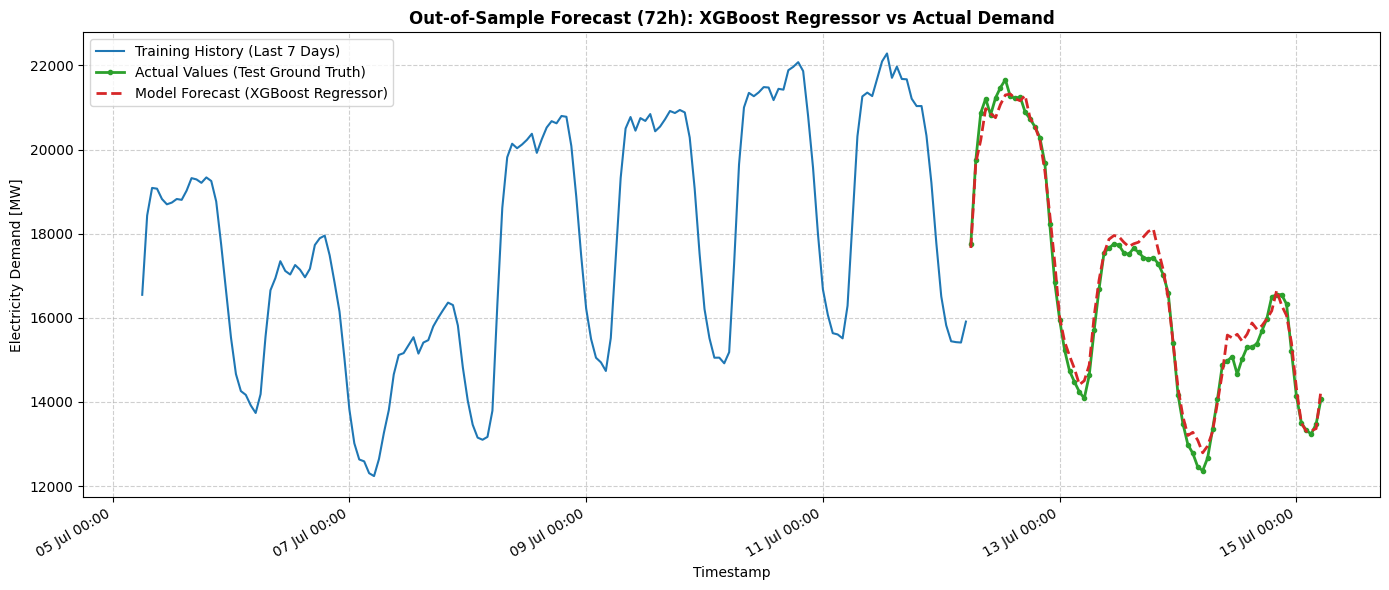

In [5]:
final_xgb = XGBRegressor(n_estimators=300, learning_rate=0.03, max_depth=5, subsample=0.85, colsample_bytree=0.85, random_state=42)
final_xgb.fit(X_train, y_train)

y_pred_xgb = pd.Series(final_xgb.predict(X_test), index=y_test.index)
m_xgb = calculate_metrics(y_test.values, y_pred_xgb.values)

print("--- FINAL XGBOOST EVALUATION METRICS (TEST 72H) ---")
for k, v in m_xgb.items():
    print(f"{k}: {v}")

fig = plot_forecast_comparison(y_train, y_test, y_pred_xgb, model_name='XGBoost Regressor')
plt.show()

pd.DataFrame({'actual': y_test, 'xgb_pred': y_pred_xgb}).to_csv('../data/processed/predictions_xgboost.csv')


### 5. Feature Importance Analysis (Gain Metric)

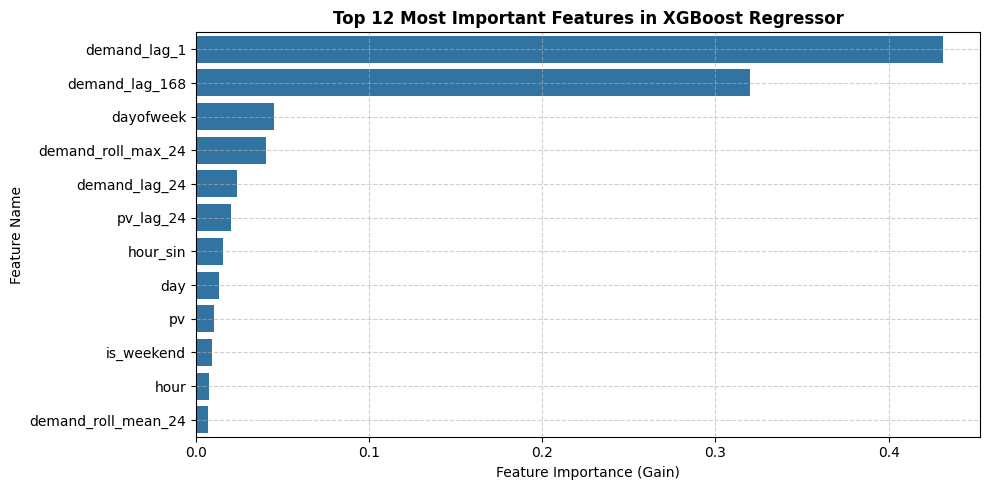

--- TOP 6 FEATURE IMPORTANCE VALUES ---
1. demand_lag_1             :  43.12% (contribution to error reduction)
2. demand_lag_168           :  31.97% (contribution to error reduction)
3. dayofweek                :   4.52% (contribution to error reduction)
4. demand_roll_max_24       :   4.02% (contribution to error reduction)
5. demand_lag_24            :   2.35% (contribution to error reduction)
6. pv_lag_24                :   2.02% (contribution to error reduction)


In [6]:
feat_imp = pd.Series(final_xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp.head(12).values, y=feat_imp.head(12).index, color='#1f77b4')
plt.title('Top 12 Most Important Features in XGBoost Regressor', fontweight='bold')
plt.xlabel('Feature Importance (Gain)')
plt.ylabel('Feature Name')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("--- TOP 6 FEATURE IMPORTANCE VALUES ---")
for rank, (feat, val) in enumerate(feat_imp.head(6).items(), 1):
    print(f"{rank}. {feat:25s}: {val*100:6.2f}% (contribution to error reduction)")


### Machine Learning Insights:
* **High Predictive Accuracy**: XGBoost achieved **RMSE: 320.79 MW** and **MAPE: 1.59%** (MAE: **253.58 MW**), reaching R² = 0.9854 and Mean Directional Accuracy MDA = 78.87%.
* **Dominant Features**: The strongest predictive signals come from direct persistence `demand_lag_1` (**43.12%**), weekly diurnal persistence `demand_lag_168` (**31.97%**), calendar indicator `dayofweek` (**4.52%**), peak rolling load `demand_roll_max_24` (**4.02%**), and day-ahead lag `demand_lag_24` (**2.35%**).
